In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

warnings.filterwarnings('ignore')
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🔥 Sẵn sàng huấn luyện trên thiết bị: {DEVICE}")

🔥 Sẵn sàng huấn luyện trên thiết bị: cuda


In [2]:
# --- ĐƯỜNG DẪN DATASET KAGGLE (ĐÃ FIX LỖI THƯ MỤC LỒNG NHAU) ---

# Thêm một cấp /WIDER_train/ và /WIDER_val/ nữa vào phần images
WIDER_TRAIN_IMG_DIR = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_train/WIDER_train/images"
WIDER_TRAIN_TXT = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_train_bbx_gt.txt"

WIDER_VAL_IMG_DIR = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images"
WIDER_VAL_TXT = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_val_bbx_gt.txt"

# (Nếu đường dẫn gốc của bạn có tiền tố là iamprateek thì sửa lại cho khớp nhé)
# Ví dụ: "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_train/WIDER_train/images"

# --- SIÊU THAM SỐ ---
LEARNING_RATE = 1e-4        
BATCH_SIZE = 16             
NUM_EPOCHS = 100
IMAGE_SIZE = 416
NUM_CLASSES = 1             
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.001

# YOLOv3 Anchors chuẩn
ANCHORS = [
    [(0.25, 0.25), (0.35, 0.35), (0.45, 0.45)],
    [(0.10, 0.10), (0.15, 0.15), (0.20, 0.20)],
    [(0.03, 0.03), (0.05, 0.05), (0.08, 0.08)],
]
S = [IMAGE_SIZE // 32, IMAGE_SIZE // 16, IMAGE_SIZE // 8]

In [3]:
def iou(box1, box2, is_pred=True):
    if is_pred:
        b1_x1 = box1[..., 0:1] - box1[..., 2:3] / 2
        b1_y1 = box1[..., 1:2] - box1[..., 3:4] / 2
        b1_x2 = box1[..., 0:1] + box1[..., 2:3] / 2
        b1_y2 = box1[..., 1:2] + box1[..., 3:4] / 2

        b2_x1 = box2[..., 0:1] - box2[..., 2:3] / 2
        b2_y1 = box2[..., 1:2] - box2[..., 3:4] / 2
        b2_x2 = box2[..., 0:1] + box2[..., 2:3] / 2
        b2_y2 = box2[..., 1:2] + box2[..., 3:4] / 2

        x1 = torch.max(b1_x1, b2_x1)
        y1 = torch.max(b1_y1, b2_y1)
        x2 = torch.min(b1_x2, b2_x2)
        y2 = torch.min(b1_y2, b2_y2)
        
        intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
        box1_area = abs((b1_x2 - b1_x1) * (b1_y2 - b1_y1))
        box2_area = abs((b2_x2 - b2_x1) * (b2_y2 - b2_y1))
        union = box1_area + box2_area - intersection
        return intersection / (union + 1e-6)
    else:
        intersection_area = torch.min(box1[..., 0], box2[..., 0]) * torch.min(box1[..., 1], box2[..., 1])
        box1_area = box1[..., 0] * box1[..., 1]
        box2_area = box2[..., 0] * box2[..., 1]
        union_area = box1_area + box2_area - intersection_area
        return intersection_area / (union_area + 1e-6)

# TÍCH HỢP SOFT-NMS ĐỂ TRÁNH MẤT MẶT KHI ĐỨNG SÁT NHAU
def soft_nms(bboxes, confidence_threshold=0.2, sigma=0.5):
    bboxes = [box for box in bboxes if box[1] > confidence_threshold]
    bboxes_after_nms = []

    while bboxes:
        chosen_idx = np.argmax([box[1] for box in bboxes])
        chosen_box = bboxes.pop(chosen_idx)
        bboxes_after_nms.append(chosen_box)

        for i in range(len(bboxes) - 1, -1, -1):
            if bboxes[i][0] != chosen_box[0]:
                continue
            iou_val = iou(torch.tensor(chosen_box[2:]), torch.tensor(bboxes[i][2:])).item()
            decay = np.exp(-(iou_val ** 2) / sigma)
            bboxes[i][1] *= decay
            if bboxes[i][1] < confidence_threshold:
                bboxes.pop(i)

    return bboxes_after_nms

In [4]:
train_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE),
    A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=[0, 0, 0], std=[1, 1, 1], max_pixel_value=255),
    ToTensorV2()
], bbox_params=A.BboxParams(format="yolo", min_visibility=0.4, label_fields=[]))

val_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE),
    A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=[0, 0, 0], std=[1, 1, 1], max_pixel_value=255),
    ToTensorV2()
], bbox_params=A.BboxParams(format="yolo", min_visibility=0.4, label_fields=[]))

class WiderFaceRawDataset(Dataset):
    def __init__(self, txt_path, image_dir, anchors, image_size=416, grid_sizes=[13, 26, 52], transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_size = image_size
        self.grid_sizes = grid_sizes
        self.anchors = torch.tensor(anchors[0] + anchors[1] + anchors[2])
        self.num_anchors_per_scale = self.anchors.shape[0] // 3
        self.ignore_iou_thresh = 0.5
        
        self.data = []
        self._parse_txt(txt_path)

    def _parse_txt(self, txt_path):
        with open(txt_path, 'r') as f:
            lines = f.readlines()
            
        i = 0
        while i < len(lines):
            img_name = lines[i].strip()
            i += 1
            if i >= len(lines): break
            num_faces = int(lines[i].strip())
            i += 1
            
            bboxes = []
            if num_faces == 0:
                i += 1 
            else:
                for _ in range(num_faces):
                    coords = list(map(int, lines[i].strip().split()[:4])) # Lấy 4 số đầu
                    bboxes.append(coords)
                    i += 1
            self.data.append((img_name, bboxes))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, bboxes = self.data[idx]
        img_path = os.path.join(self.image_dir, img_name)
        
        image = cv2.imread(img_path)
        if image is None: 
            return torch.zeros((3, self.image_size, self.image_size)), tuple([torch.zeros((self.num_anchors_per_scale, s, s, 6)) for s in self.grid_sizes])
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_h, img_w, _ = image.shape
        
        yolo_bboxes = []
        for (x1, y1, bw, bh) in bboxes:
            if bw <= 1 or bh <= 1: continue 
            x_center = max(0.001, min(0.999, (x1 + bw / 2) / img_w))
            y_center = max(0.001, min(0.999, (y1 + bh / 2) / img_h))
            width = max(0.001, min(1.0, bw / img_w))
            height = max(0.001, min(1.0, bh / img_h))
            yolo_bboxes.append([x_center, y_center, width, height, 0])

        if self.transform:
            try:
                augmented = self.transform(image=image, bboxes=yolo_bboxes)
                image = augmented["image"]
                yolo_bboxes = augmented["bboxes"]
            except:
                image = val_transforms(image=image, bboxes=[])["image"]
                yolo_bboxes = []

        targets = [torch.zeros((self.num_anchors_per_scale, s, s, 6)) for s in self.grid_sizes]
        for box in yolo_bboxes:
            x, y, width, height, class_label = box
            iou_anchors = iou(torch.tensor(box[2:4]), self.anchors, is_pred=False)
            anchor_indices = iou_anchors.argsort(descending=True, dim=0)
            has_anchor = [False] * 3
            
            for anchor_idx in anchor_indices:
                scale_idx = anchor_idx // self.num_anchors_per_scale
                anchor_on_scale = anchor_idx % self.num_anchors_per_scale
                s = self.grid_sizes[scale_idx]
                
                i, j = max(0, min(s-1, int(s * y))), max(0, min(s-1, int(s * x)))
                anchor_taken = targets[scale_idx][anchor_on_scale, i, j, 0]
                if not anchor_taken and not has_anchor[scale_idx]:
                    targets[scale_idx][anchor_on_scale, i, j, 0] = 1
                    targets[scale_idx][anchor_on_scale, i, j, 1:5] = torch.tensor([s * x - j, s * y - i, width * s, height * s])
                    targets[scale_idx][anchor_on_scale, i, j, 5] = int(class_label)
                    has_anchor[scale_idx] = True
                elif not anchor_taken and iou_anchors[anchor_idx] > self.ignore_iou_thresh:
                    targets[scale_idx][anchor_on_scale, i, j, 0] = -1

        return image, tuple(targets)

# Tạo DataLoader
train_dataset = WiderFaceRawDataset(txt_path=WIDER_TRAIN_TXT, image_dir=WIDER_TRAIN_IMG_DIR, anchors=ANCHORS, transform=train_transforms)
val_dataset = WiderFaceRawDataset(txt_path=WIDER_VAL_TXT, image_dir=WIDER_VAL_IMG_DIR, anchors=ANCHORS, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"✅ Đã load xong Data! Train: {len(train_dataset)} ảnh | Val: {len(val_dataset)} ảnh")

✅ Đã load xong Data! Train: 12880 ảnh | Val: 3226 ảnh


🔍 Đang xuất Sample Data từ tập Train (Kèm Bounding Box gốc):


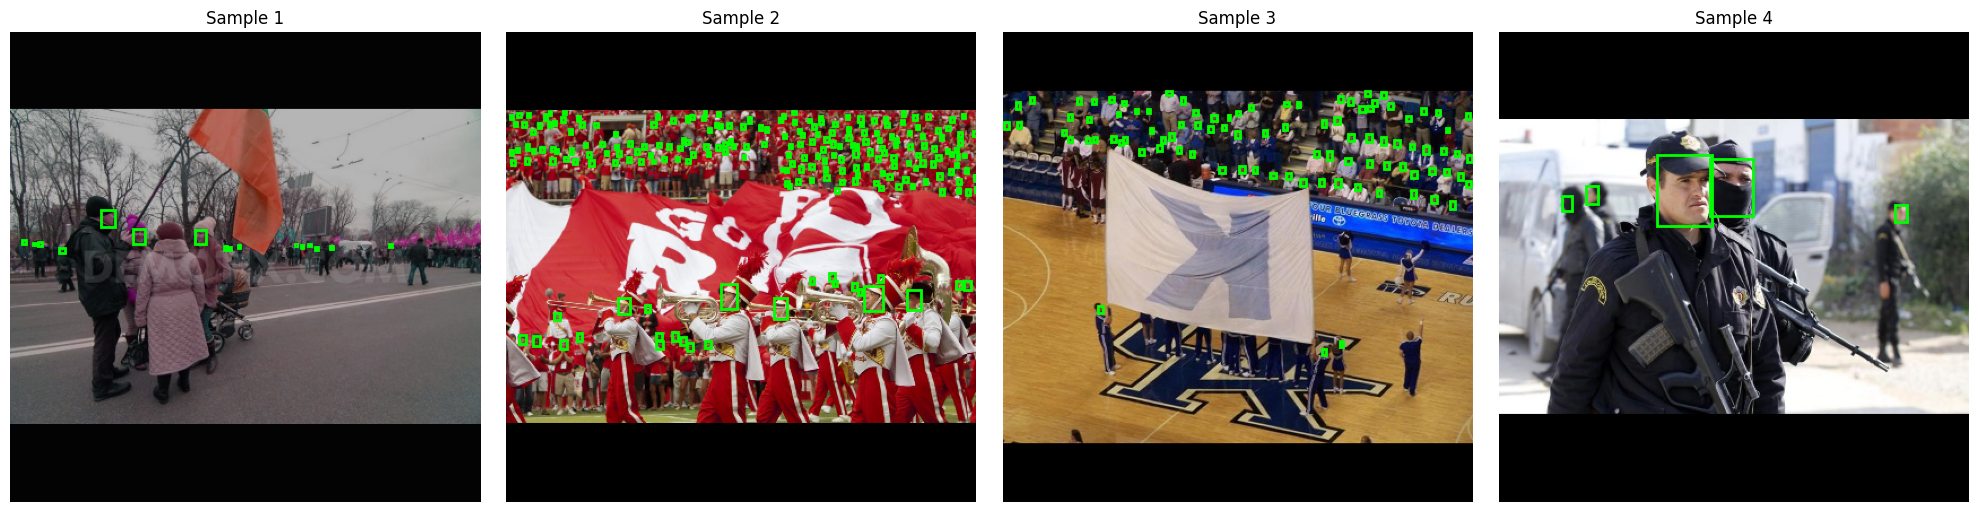

In [5]:
def visualize_dataset_samples(dataloader, num_samples=4):
    images, targets = next(iter(dataloader))
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
    
    for i in range(num_samples):
        img = images[i].permute(1, 2, 0).numpy()
        # Denormalize
        img = np.clip(img * 255, 0, 255).astype(np.uint8)
        
        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')
        
        # Vẽ boxes từ targets (Scale 52x52 - chứa nhiều box nhất)
        target_52 = targets[2][i] # Lấy scale lớn nhất
        h, w, _ = img.shape
        
        for anchor_idx in range(3):
            for row in range(52):
                for col in range(52):
                    if target_52[anchor_idx, row, col, 0] == 1:
                        box = target_52[anchor_idx, row, col, 1:5]
                        x_cell, y_cell, w_cell, h_cell = box
                        
                        x = (x_cell + col) / 52.0
                        y = (y_cell + row) / 52.0
                        bw = w_cell / 52.0
                        bh = h_cell / 52.0
                        
                        x_min = (x - bw/2) * w
                        y_min = (y - bh/2) * h
                        
                        rect = patches.Rectangle((x_min, y_min), bw*w, bh*h, linewidth=2, edgecolor='lime', facecolor='none')
                        ax.add_patch(rect)
        ax.set_title(f"Sample {i+1}")
    plt.tight_layout()
    plt.show()

print("🔍 Đang xuất Sample Data từ tập Train (Kèm Bounding Box gốc):")
visualize_dataset_samples(train_loader)

In [6]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_batch_norm=True, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=not use_batch_norm, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels) if use_batch_norm else nn.Identity()
        self.activation = nn.LeakyReLU(0.1)
        self.use_batch_norm = use_batch_norm

    def forward(self, x):
        return self.activation(self.bn(self.conv(x))) if self.use_batch_norm else self.conv(x)

class ResidualBlock(nn.Module):
    def __init__(self, channels, use_residual=True, num_repeats=1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, channels // 2, kernel_size=1),
                nn.BatchNorm2d(channels // 2),
                nn.LeakyReLU(0.1),
                nn.Conv2d(channels // 2, channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(channels),
                nn.LeakyReLU(0.1)
            ) for _ in range(num_repeats)
        ])
        self.use_residual = use_residual

    def forward(self, x):
        for layer in self.layers:
            x = x + layer(x) if self.use_residual else layer(x)
        return x

class ScalePrediction(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_prob=0.0):
        super().__init__()
        self.pred = nn.Sequential(
            nn.Conv2d(in_channels, 2 * in_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(2 * in_channels),
            nn.LeakyReLU(0.1),
            nn.Dropout2d(p=dropout_prob) if dropout_prob > 0 else nn.Identity(),
            nn.Conv2d(2 * in_channels, (num_classes + 5) * 3, kernel_size=1)
        )
        self.num_classes = num_classes

    def forward(self, x):
        output = self.pred(x)
        return output.view(x.size(0), 3, self.num_classes + 5, x.size(2), x.size(3)).permute(0, 1, 3, 4, 2)

class YOLOv3(nn.Module):
    def __init__(self, in_channels=3, num_classes=1):
        super().__init__()
        self.layers = nn.ModuleList([
            CNNBlock(in_channels, 32, kernel_size=3, stride=1, padding=1),
            CNNBlock(32, 64, kernel_size=3, stride=2, padding=1),
            ResidualBlock(64, num_repeats=1),
            CNNBlock(64, 128, kernel_size=3, stride=2, padding=1),
            ResidualBlock(128, num_repeats=2),
            CNNBlock(128, 256, kernel_size=3, stride=2, padding=1),
            ResidualBlock(256, num_repeats=8),
            CNNBlock(256, 512, kernel_size=3, stride=2, padding=1),
            ResidualBlock(512, num_repeats=8),
            CNNBlock(512, 1024, kernel_size=3, stride=2, padding=1),
            ResidualBlock(1024, num_repeats=4),
            CNNBlock(1024, 512, kernel_size=1, stride=1, padding=0),
            CNNBlock(512, 1024, kernel_size=3, stride=1, padding=1),
            CNNBlock(1024, 512, kernel_size=1, stride=1, padding=0),
            CNNBlock(512, 1024, kernel_size=3, stride=1, padding=1),
            CNNBlock(1024, 512, kernel_size=1, stride=1, padding=0),
        ])

        self.scale1_pred = nn.Sequential(CNNBlock(512, 1024, kernel_size=3, stride=1, padding=1), ScalePrediction(1024, num_classes))
        self.scale1_upsample = CNNBlock(512, 256, kernel_size=1, stride=1, padding=0)
        self.upsample = nn.Upsample(scale_factor=2)

        self.scale2_layers = nn.Sequential(
            CNNBlock(768, 256, kernel_size=1, stride=1, padding=0),
            CNNBlock(256, 512, kernel_size=3, stride=1, padding=1),
            CNNBlock(512, 256, kernel_size=1, stride=1, padding=0),
            CNNBlock(256, 512, kernel_size=3, stride=1, padding=1),
            CNNBlock(512, 256, kernel_size=1, stride=1, padding=0),
        )
        self.scale2_pred = nn.Sequential(CNNBlock(256, 512, kernel_size=3, stride=1, padding=1), ScalePrediction(512, num_classes))
        self.scale2_upsample = CNNBlock(256, 128, kernel_size=1, stride=1, padding=0)

        self.scale3_layers = nn.Sequential(
            CNNBlock(384, 128, kernel_size=1, stride=1, padding=0),
            CNNBlock(128, 256, kernel_size=3, stride=1, padding=1),
            CNNBlock(256, 128, kernel_size=1, stride=1, padding=0),
            CNNBlock(128, 256, kernel_size=3, stride=1, padding=1),
            CNNBlock(256, 128, kernel_size=1, stride=1, padding=0),
        )
        self.scale3_pred = nn.Sequential(CNNBlock(128, 256, kernel_size=3, stride=1, padding=1), ScalePrediction(256, num_classes))

    def forward(self, x):
        outputs = []
        route_connections = {}
        for i, layer in enumerate(self.layers):
            x = layer(x)
            outputs.append(x)
            if i == 6: route_connections['52x52'] = x
            elif i == 8: route_connections['26x26'] = x

        scale1_output = self.scale1_pred(x)
        x = self.upsample(self.scale1_upsample(x))
        x = torch.cat([x, route_connections['26x26']], dim=1)

        x = self.scale2_layers(x)
        scale2_output = self.scale2_pred(x)
        
        x = self.upsample(self.scale2_upsample(x))
        x = torch.cat([x, route_connections['52x52']], dim=1)

        x = self.scale3_layers(x)
        scale3_output = self.scale3_pred(x)
        return scale1_output, scale2_output, scale3_output

In [7]:
class YOLOLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.cross_entropy = nn.CrossEntropyLoss()
        self.sigmoid = nn.Sigmoid()

    def forward(self, predictions, target, anchors):
        obj = target[..., 0] == 1
        no_obj = target[..., 0] == 0

        no_object_loss = self.bce(predictions[..., 0:1][no_obj], target[..., 0:1][no_obj])
        anchors = anchors.reshape(1, 3, 1, 1, 2)
        box_preds = torch.cat([self.sigmoid(predictions[..., 1:3]), torch.exp(predictions[..., 3:5]) * anchors], dim=-1)
        
        ious = iou(box_preds[obj], target[..., 1:5][obj]).detach()
        object_loss = self.mse(self.sigmoid(predictions[..., 0:1][obj]), ious * target[..., 0:1][obj])

        predictions[..., 1:3] = self.sigmoid(predictions[..., 1:3])
        target[..., 3:5] = torch.log(1e-6 + target[..., 3:5] / anchors)
        box_loss = self.mse(predictions[..., 1:5][obj], target[..., 1:5][obj])
        
        class_loss = self.cross_entropy(predictions[..., 5:][obj], target[..., 5][obj].long())
        return box_loss + object_loss + no_object_loss + class_loss

In [8]:
model = YOLOv3(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
loss_fn = YOLOLoss()
scaler = torch.cuda.amp.GradScaler()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaled_anchors = (torch.tensor(ANCHORS) * torch.tensor(S).unsqueeze(1).unsqueeze(1).repeat(1, 3, 2)).to(DEVICE)

history = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val_loss = float('inf')
epochs_without_improve = 0

print("\n🚀 BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN...")
for epoch in range(NUM_EPOCHS):
    # --- TRAINING ---
    model.train()
    total_train_loss = 0
    loop = tqdm(train_loader, leave=True, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    
    for batch_idx, (images, targets) in enumerate(loop):
        images = images.to(DEVICE)
        targets = [target.to(DEVICE) for target in targets]
        
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = sum([loss_fn(outputs[i], targets[i], scaled_anchors[i]) for i in range(3)])

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()
        loop.set_postfix({'loss': loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    
    # --- VALIDATION ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]"):
            images = images.to(DEVICE)
            targets = [target.to(DEVICE) for target in targets]
            outputs = model(images)
            loss = sum([loss_fn(outputs[i], targets[i], scaled_anchors[i]) for i in range(3)])
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    scheduler.step(avg_val_loss)
    
    # --- LƯU LOG ---
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['lr'].append(current_lr)
    
    print(f"📊 TỔNG KẾT EPOCH {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.1e}")

    # --- EARLY STOPPING ---
    if avg_val_loss + EARLY_STOPPING_MIN_DELTA < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improve = 0
        torch.save(model.state_dict(), "best_yolov3_widerface.pth")
        print("✅ Đã lưu model tốt nhất!")
    else:
        epochs_without_improve += 1

    if epochs_without_improve >= EARLY_STOPPING_PATIENCE:
        print(f"🛑 Kích hoạt Early Stopping tại Epoch {epoch+1} vì Val Loss không giảm.")
        break


🚀 BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN...


Epoch 1/100 [Val]: 100%|██████████| 202/202 [01:06<00:00,  3.04it/s]


📊 TỔNG KẾT EPOCH 1: Train Loss: 1.2233 | Val Loss: 0.7909 | LR: 1.0e-04
✅ Đã lưu model tốt nhất!


Epoch 2/100 [Val]: 100%|██████████| 202/202 [01:04<00:00,  3.13it/s]


📊 TỔNG KẾT EPOCH 2: Train Loss: 0.7173 | Val Loss: 0.5987 | LR: 1.0e-04
✅ Đã lưu model tốt nhất!


...

📊 TỔNG KẾT EPOCH 42: Train Loss: 0.1560 | Val Loss: 0.2615 | LR: 1.3e-05


Epoch 43/100 [Val]: 100%|██████████| 202/202 [01:05<00:00,  3.11it/s]


📊 TỔNG KẾT EPOCH 43: Train Loss: 0.1532 | Val Loss: 0.2603 | LR: 6.3e-06


Epoch 44/100 [Val]: 100%|██████████| 202/202 [01:05<00:00,  3.08it/s]

📊 TỔNG KẾT EPOCH 44: Train Loss: 0.1478 | Val Loss: 0.2663 | LR: 6.3e-06
🛑 Kích hoạt Early Stopping tại Epoch 44 vì Val Loss không giảm.


📈 Đang xuất biểu đồ huấn luyện:


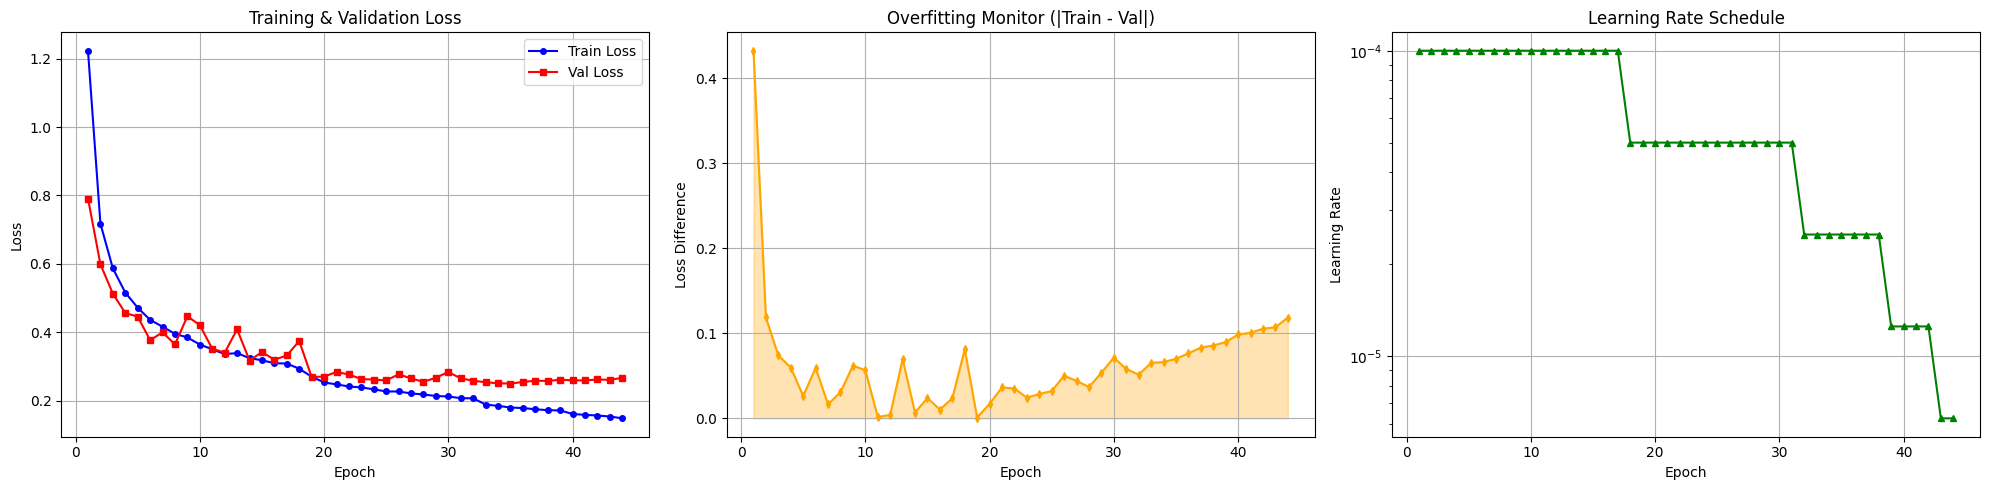

In [9]:
def plot_training_results(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Biểu đồ 1: Train & Val Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss', markersize=4)
    axes[0].set_title('Training & Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)
    axes[0].legend()
    
    # Biểu đồ 2: Overfitting Monitor
    loss_diff = [abs(t - v) for t, v in zip(history['train_loss'], history['val_loss'])]
    axes[1].plot(epochs, loss_diff, 'orange', marker='d', markersize=4)
    axes[1].fill_between(epochs, loss_diff, alpha=0.3, color='orange')
    axes[1].set_title('Overfitting Monitor (|Train - Val|)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss Difference')
    axes[1].grid(True)
    
    # Biểu đồ 3: Learning Rate
    axes[2].plot(epochs, history['lr'], 'g-^', markersize=4)
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_yscale('log')
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()

print("📈 Đang xuất biểu đồ huấn luyện:")
plot_training_results(history)


🔎 BẮT ĐẦU TEST MODEL TRÊN DỮ LIỆU THỰC TẾ...
✅ Đã load model tốt nhất từ: best_yolov3_widerface.pth
📁 Tìm thấy 16097 ảnh trong tập Test.


NameError: name 'convert_cells_to_bboxes' is not defined

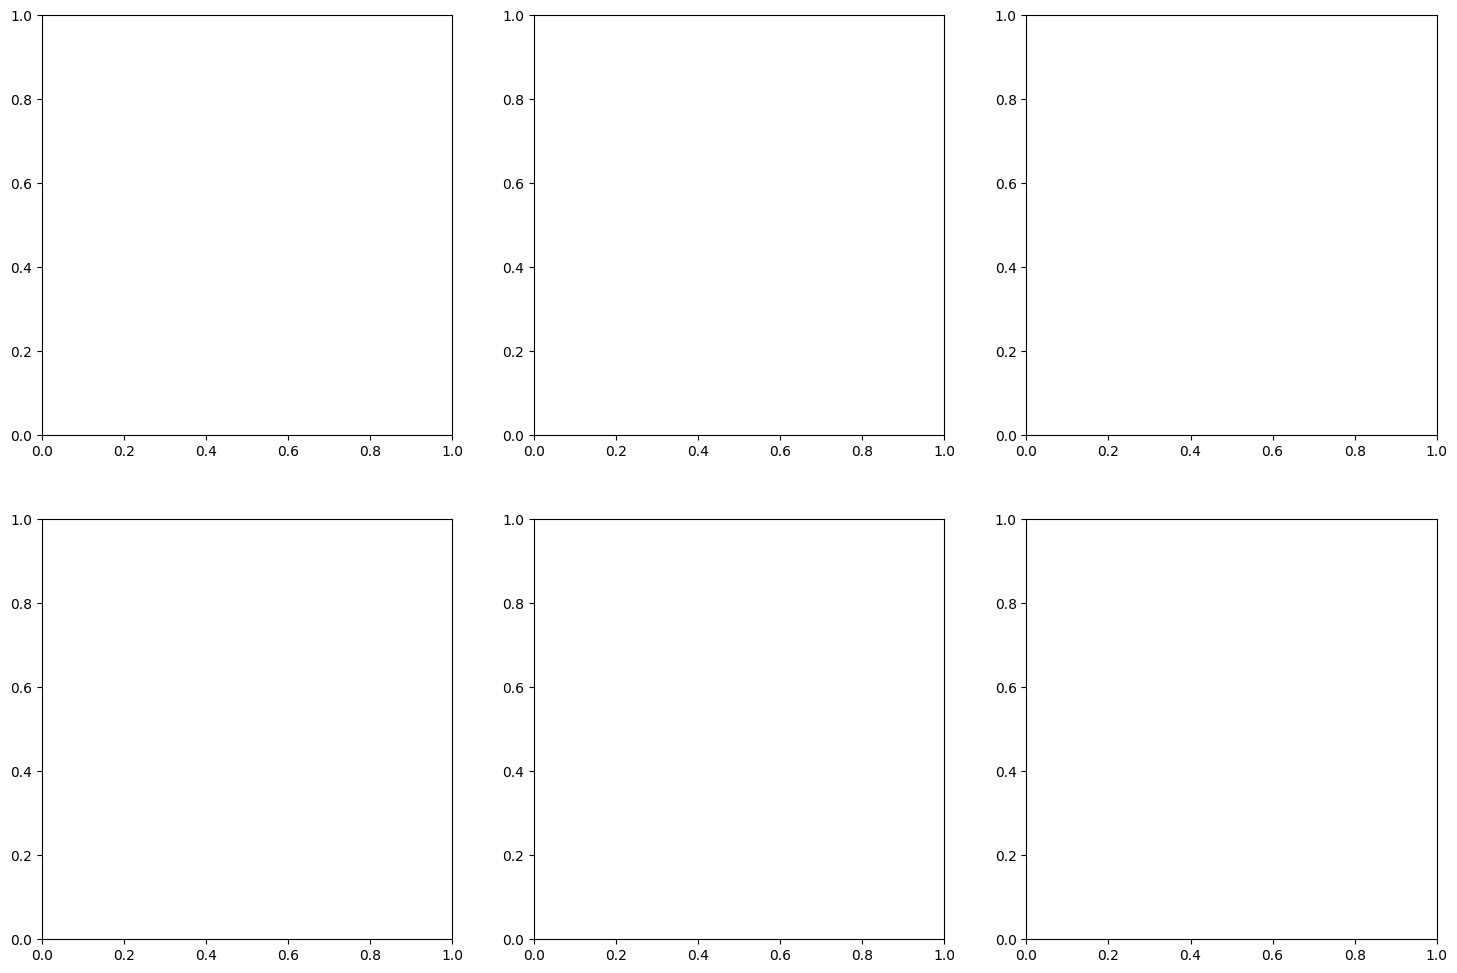

In [10]:
import random

# --- CẤU HÌNH ĐƯỜNG DẪN TẬP TEST ---
# Thay đổi đường dẫn này cho khớp với cấu trúc thư mục của Kaggle của bạn
WIDER_TEST_IMG_DIR = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_test/WIDER_test/images"
WIDER_TEST_TXT = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_test_filelist.txt"

def test_and_visualize(model_path="best_yolov3_widerface.pth", num_samples=6):
    # 1. Khởi tạo và Load Model tốt nhất (từ Cell 8)
    model = YOLOv3(num_classes=NUM_CLASSES).to(DEVICE)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        print(f"✅ Đã load model tốt nhất từ: {model_path}")
    else:
        print("⚠️ Không tìm thấy file model. Đang dùng trọng số hiện tại trên RAM.")
    
    model.eval()

    # 2. Đọc file text chứa danh sách ảnh test
    with open(WIDER_TEST_TXT, 'r') as f:
        # Chỉ lấy các dòng chứa tên file ảnh hợp lệ (.jpg)
        test_images = [line.strip() for line in f.readlines() if line.strip().endswith('.jpg')]
        
    print(f"📁 Tìm thấy {len(test_images)} ảnh trong tập Test.")

    # 3. Chọn ngẫu nhiên vài ảnh để test
    sample_images = random.sample(test_images, num_samples)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # Tính toán Anchor Box Scaled cho Inference
    scaled_anchors = (torch.tensor(ANCHORS) * torch.tensor(S).unsqueeze(1).unsqueeze(1).repeat(1, 3, 2)).to(DEVICE)

    for idx, img_name in enumerate(sample_images):
        img_path = os.path.join(WIDER_TEST_IMG_DIR, img_name)
        
        # Đọc ảnh
        image = cv2.imread(img_path)
        if image is None:
            print(f"Lỗi: Không đọc được ảnh {img_path}")
            continue
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_h, original_w, _ = image.shape

        # Tiền xử lý ảnh (Resize & Normalize giống hệt lúc Val)
        transformed = val_transforms(image=image, bboxes=[])
        img_tensor = transformed["image"].unsqueeze(0).to(DEVICE)

        # 4. Chạy Model dự đoán (Forward Pass)
        with torch.no_grad():
            outputs = model(img_tensor)
            bboxes = []
            
            # Thu thập bboxes từ cả 3 Scale (13x13, 26x26, 52x52)
            for i in range(3):
                boxes_scale = convert_cells_to_bboxes(outputs[i], scaled_anchors[i], S[i], is_predictions=True)
                bboxes += boxes_scale[0] # Lấy batch đầu tiên (batch_size = 1)

            # Áp dụng Soft-NMS để lọc các box bị trùng lấn
            nms_boxes = soft_nms(bboxes, confidence_threshold=0.5, sigma=0.5)

        # 5. Vẽ ảnh và Bounding Box
        ax = axes[idx]
        ax.imshow(image)
        ax.axis('off')
        
        # Lấy tên file ngắn gọn để hiển thị
        short_name = img_name.split('/')[-1]
        ax.set_title(f"Ảnh: {short_name}\nPhát hiện: {len(nms_boxes)} khuôn mặt", fontsize=11, fontweight='bold')

        # Vẽ từng khuôn mặt được phát hiện
        for box in nms_boxes:
            class_pred, conf, x_c, y_c, w, h = box
            
            # Chuyển đổi tọa độ YOLO [0, 1] về tọa độ Pixel thật của ảnh gốc
            x_min = (x_c - w/2) * original_w
            y_min = (y_c - h/2) * original_h
            box_w = w * original_w
            box_h = h * original_h

            # Vẽ Box vuông
            rect = patches.Rectangle((x_min, y_min), box_w, box_h, linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            
            # Hiển thị điểm Confidence (Tỉ lệ tin cậy)
            ax.text(x_min, y_min - 5, f"{conf:.2f}", color='black', fontsize=9, weight='bold', 
                    bbox=dict(facecolor='lime', alpha=0.8, pad=1, edgecolor='none'))

    plt.tight_layout()
    plt.show()

# Chạy lệnh
print("\n🔎 BẮT ĐẦU TEST MODEL TRÊN DỮ LIỆU THỰC TẾ...")
test_and_visualize(model_path="best_yolov3_widerface.pth", num_samples=6)

In [ ]:
!pip install seaborn -q
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# --- 1. Hàm tính IoU giữa 2 Box tọa độ Pixel [x_min, y_min, w, h] ---
def calculate_pixel_iou(box1, box2):
    x1_min, y1_min, w1, h1 = box1
    x1_max, y1_max = x1_min + w1, y1_min + h1
    
    x2_min, y2_min, w2, h2 = box2
    x2_max, y2_max = x2_min + w2, y2_min + h2
    
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    inter_w = max(0, inter_x_max - inter_x_min)
    inter_h = max(0, inter_y_max - inter_y_min)
    inter_area = inter_w * inter_h
    
    union_area = w1 * h1 + w2 * h2 - inter_area
    return inter_area / (union_area + 1e-6)

# --- 2. Hàm Phân tích đáp án gốc từ file Txt ---
def parse_val_ground_truth(txt_path):
    gt_dict = {}
    with open(txt_path, 'r') as f:
        lines = f.readlines()
    i = 0
    while i < len(lines):
        img_name = lines[i].strip()
        i += 1
        if i >= len(lines): break
        num_faces = int(lines[i].strip())
        i += 1
        bboxes = []
        if num_faces == 0:
            i += 1
        else:
            for _ in range(num_faces):
                coords = list(map(int, lines[i].strip().split()[:4]))
                if coords[2] > 1 and coords[3] > 1: # Lọc box bị lỗi diện tích
                    bboxes.append(coords)
                i += 1
        gt_dict[img_name] = bboxes
    return gt_dict

# --- 3. HÀM CHÍNH: CHẠY ĐÁNH GIÁ & VẼ MA TRẬN ---
def evaluate_and_plot_confusion_matrix(model_path="best_yolov3_widerface.pth", iou_threshold=0.5, conf_threshold=0.5, max_images=500):
    print(f"Loading model từ: {model_path}...")
    model = YOLOv3(num_classes=NUM_CLASSES).to(DEVICE)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # Tải đáp án chuẩn (Ground Truth)
    gt_dict = parse_val_ground_truth(WIDER_VAL_TXT)
    print(f"📁 Đã load đáp án của {len(gt_dict)} ảnh Validation.")
    
    TP, FP, FN = 0, 0, 0
    scaled_anchors = (torch.tensor(ANCHORS) * torch.tensor(S).unsqueeze(1).unsqueeze(1).repeat(1, 3, 2)).to(DEVICE)
    
    # Giới hạn số lượng ảnh test để chạy nhanh hơn (Nếu muốn test hết, đổi max_images=None)
    img_list = list(gt_dict.keys())[:max_images] if max_images else list(gt_dict.keys())
    
    print("\n🚀 Đang chạy dự đoán và so sánh (Quá trình này mất vài phút)...")
    for img_name in tqdm(img_list):
        img_path = os.path.join(WIDER_VAL_IMG_DIR, img_name)
        image = cv2.imread(img_path)
        if image is None: continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_h, orig_w, _ = image.shape
        
        # Tiền xử lý ảnh đẩy vào Model
        transformed = val_transforms(image=image, bboxes=[])
        img_tensor = transformed["image"].unsqueeze(0).to(DEVICE)
        
        # Chạy Model
        with torch.no_grad():
            outputs = model(img_tensor)
            bboxes = []
            for i in range(3):
                boxes_scale = convert_cells_to_bboxes(outputs[i], scaled_anchors[i], S[i], is_predictions=True)
                bboxes += boxes_scale[0]
            # Lọc box rác bằng Soft-NMS
            nms_boxes = soft_nms(bboxes, confidence_threshold=conf_threshold, sigma=0.5)
            
        # Chuyển đổi Box dự đoán về Pixel thật [x_min, y_min, w, h]
        pred_boxes = []
        for box in nms_boxes:
            _, conf, x_c, y_c, w_norm, h_norm = box
            w = w_norm * orig_w
            h = h_norm * orig_h
            x_min = (x_c - w_norm/2) * orig_w
            y_min = (y_c - h_norm/2) * orig_h
            pred_boxes.append([x_min, y_min, w, h, conf])
            
        # --- THUẬT TOÁN ĐÁNH GIÁ (MATCHING PRED vs TRUTH) ---
        true_boxes = gt_dict[img_name]
        pred_boxes.sort(key=lambda x: x[4], reverse=True) # Ưu tiên box có độ tự tin cao nhất
        matched_gt = set()
        
        for pred in pred_boxes:
            best_iou = 0
            best_gt_idx = -1
            
            # Tìm khuôn mặt thực tế khớp nhất với Box dự đoán
            for gt_idx, gt in enumerate(true_boxes):
                if gt_idx in matched_gt: continue # Bỏ qua mặt đã được chấm điểm
                iou_val = calculate_pixel_iou(pred[:4], gt)
                if iou_val > best_iou:
                    best_iou = iou_val
                    best_gt_idx = gt_idx
                    
            if best_iou >= iou_threshold:
                TP += 1                      # Đoán Trúng!
                matched_gt.add(best_gt_idx)
            else:
                FP += 1                      # Đoán Sai (Nhìn nhầm cảnh vật)
                
        # Tính số khuôn mặt bị bỏ sót
        FN += (len(true_boxes) - len(matched_gt))

    # --- 4. TÍNH TOÁN METRICS VÀ VẼ MA TRẬN ---
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print("\n" + "="*40)
    print("🏆 KẾT QUẢ ĐÁNH GIÁ (EVALUATION METRICS) 🏆")
    print(f"Tổng số khuôn mặt thực tế : {TP + FN}")
    print(f"Tổng số Box model dự đoán : {TP + FP}")
    print(f"-> True Positive (TP - Đoán Trúng) : {TP}")
    print(f"-> False Positive (FP - Bắt Nhầm)  : {FP}")
    print(f"-> False Negative (FN - Bỏ Sót)    : {FN}")
    print("-" * 40)
    print(f"🎯 Precision (Độ chính xác) : {precision:.4f} (Khi khoanh thì chuẩn {precision*100:.1f}%)")
    print(f"🎯 Recall (Độ bao phủ)      : {recall:.4f} (Tìm được {recall*100:.1f}% tổng số mặt)")
    print(f"🎯 F1-Score                 : {f1_score:.4f}")
    print("="*40)

    # Dựng Ma trận nhầm lẫn
    cm = np.array([[TP, FN], 
                   [FP, 0]]) # TN = 0 vì không đếm được số "Background"

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16},
                xticklabels=['Dự đoán Face', 'Dự đoán Background'],
                yticklabels=['Thực tế Face', 'Thực tế Background'])
    plt.title(f'Confusion Matrix - Face Detection\nIoU Thresh: {iou_threshold} | Conf Thresh: {conf_threshold}', 
              fontsize=14, pad=15)
    plt.ylabel('Ground Truth (Sự thật)', fontsize=12, fontweight='bold')
    plt.xlabel('Prediction (Mô hình dự đoán)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# CHẠY LỆNH ĐÁNH GIÁ
# Lưu ý: Tập Val có ~3200 ảnh, tôi đang set max_images=500 để bạn chạy test thử nhanh. 
# Nếu muốn đánh giá FULL để báo cáo, hãy xóa chữ max_images=500 đi nhé!
evaluate_and_plot_confusion_matrix(model_path="best_yolov3_widerface.pth", max_images=500)